# Analysis of Structural Balance in Signed Financial Networks

This notebook presents a production-grade investigation of structural balance properties and local cohesive structures (fraudster groups) within a signed financial social network. We utilize eigenvalue exponents for global balance quantification ($B_w$), non-binary triangle geometric means, Kolmogorov-Smirnov statistical comparison against weight-shuffled null ensembles, and community detection on suspected actors.

## 1. Setup and Environment Configuration
We load the necessary libraries, auto-reload helpers, and set simulation parameters (e.g. number of randomized null runs).

In [1]:
%load_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import json
from collections import defaultdict
from auxiliary_functions import *

## 2. Graph Loading and Simplification
We read the raw GEXF network `graph_jupyter.gexf` and simplify it into undirected signed graphs by consolidating parallel links:
- **Continuous Simplified Graph:** Retains the continuous mean weights of parallel edges.
- **Binary Simplified Graph:** Maps consolidated weights to their signs ($-1.0$ or $+1.0$).

In [2]:
std_threshold = 0.5
NumberOfRandoms = 300

# Load raw graph
graph_raw = nx.read_gexf("graph_jupyter.gexf")

# 1. Continuous Graph simplification
graph = simplify_graph(graph_raw, std_threshold, continuous=True)
null_models = [generate_null_model(graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]

triangles_graph = calculate_triangles_graph(graph)
null_triangles = calculate_triangles_null_graph(null_models)

print(f"Continuous Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Continuous Graph: 5866 nodes, 21219 edges


## 3. Global Exploratory Data Analysis (EDA)
We analyze global edge weights, signs, and triangle configurations.

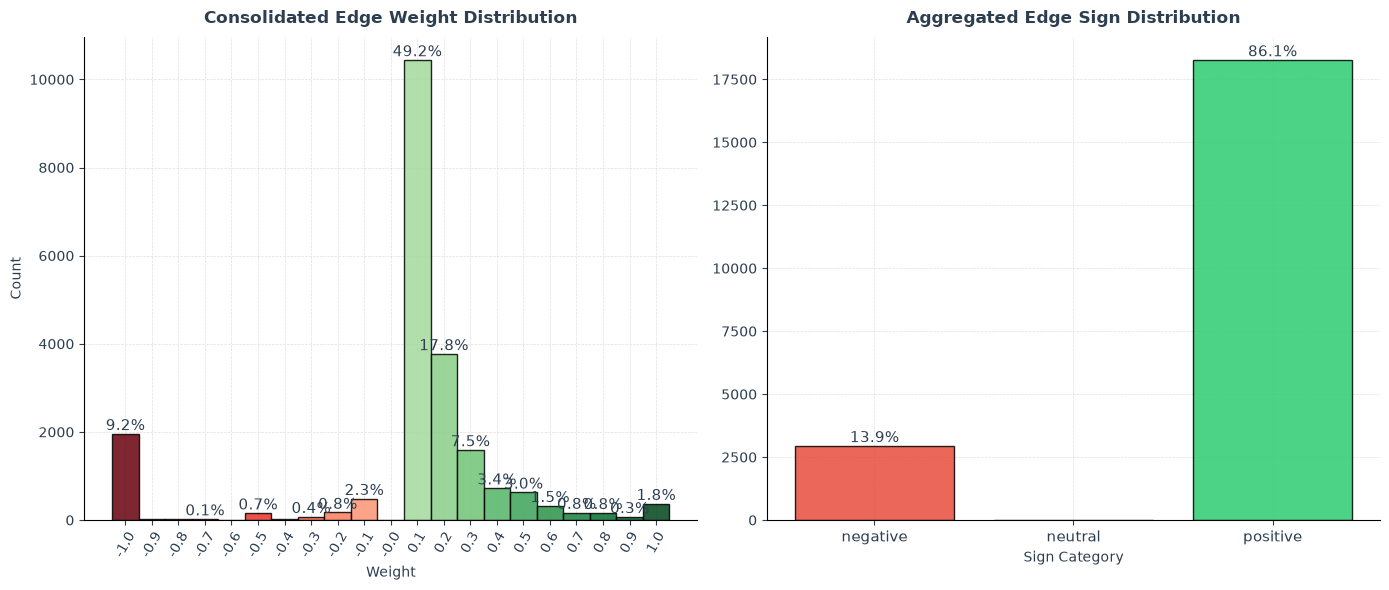

In [3]:
plot_weight_distribution(graph)

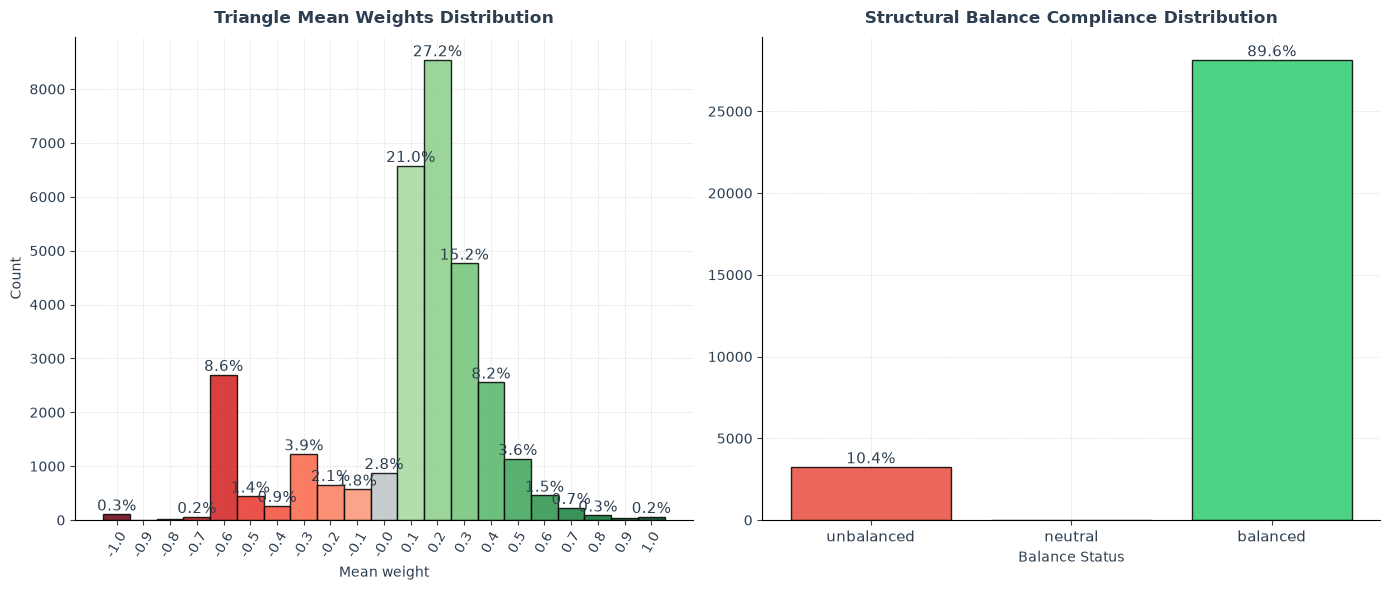

In [4]:
plot_triangle_distribution(triangles_graph)

In [5]:
number_of_triangles_per_type(triangles_graph)

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
0,233,4938,3017,23203


## 4. Ego-Network Analysis of Suspicious Nodes
We extract subgraphs centered on the top-5 nodes with the most negative and $-1.0$ weight incident links to inspect local threat clusters.

In [6]:
# Count negative connections per node
negative_edges_count = defaultdict(lambda: [0, 0])
for u, v, data in graph.edges(data=True):
    w = float(data["weight"])
    if w < 0:
        negative_edges_count[u][0] += 1
        negative_edges_count[v][0] += 1
    if w == -1.0:
        negative_edges_count[u][1] += 1
        negative_edges_count[v][1] += 1

top_neg_nodes = sorted(negative_edges_count.keys(), key=lambda n: negative_edges_count[n][0], reverse=True)[:5]
top_neg1_nodes = sorted(negative_edges_count.keys(), key=lambda n: negative_edges_count[n][1], reverse=True)[:5]

print(f"Top nodes with most negative links: {top_neg_nodes}")
print(f"Top nodes with most -1.0 links: {top_neg1_nodes}")

# Compose subgraphs
negative_graph = nx.compose_all([nx.ego_graph(graph, node, radius=1) for node in top_neg_nodes])
negative1_graph = nx.compose_all([nx.ego_graph(graph, node, radius=1) for node in top_neg1_nodes])

# Save GEXF subgraphs for external visual tools (e.g. Gephi)
nx.write_gexf(negative_graph, "negative_graph.gexf")
nx.write_gexf(negative1_graph, "negative1_graph.gexf")

print(f"\nNegative Subgraph: {negative_graph.number_of_nodes()} nodes, {negative_graph.number_of_edges()} edges")
print(f"Negative1 Subgraph: {negative1_graph.number_of_nodes()} nodes, {negative1_graph.number_of_edges()} edges")

Top nodes with most negative links: ['2125', '1810', '2266', '3744', '2067']
Top nodes with most -1.0 links: ['1810', '2125', '3744', '4172', '2067']

Negative Subgraph: 997 nodes, 4571 edges
Negative1 Subgraph: 1076 nodes, 5261 edges


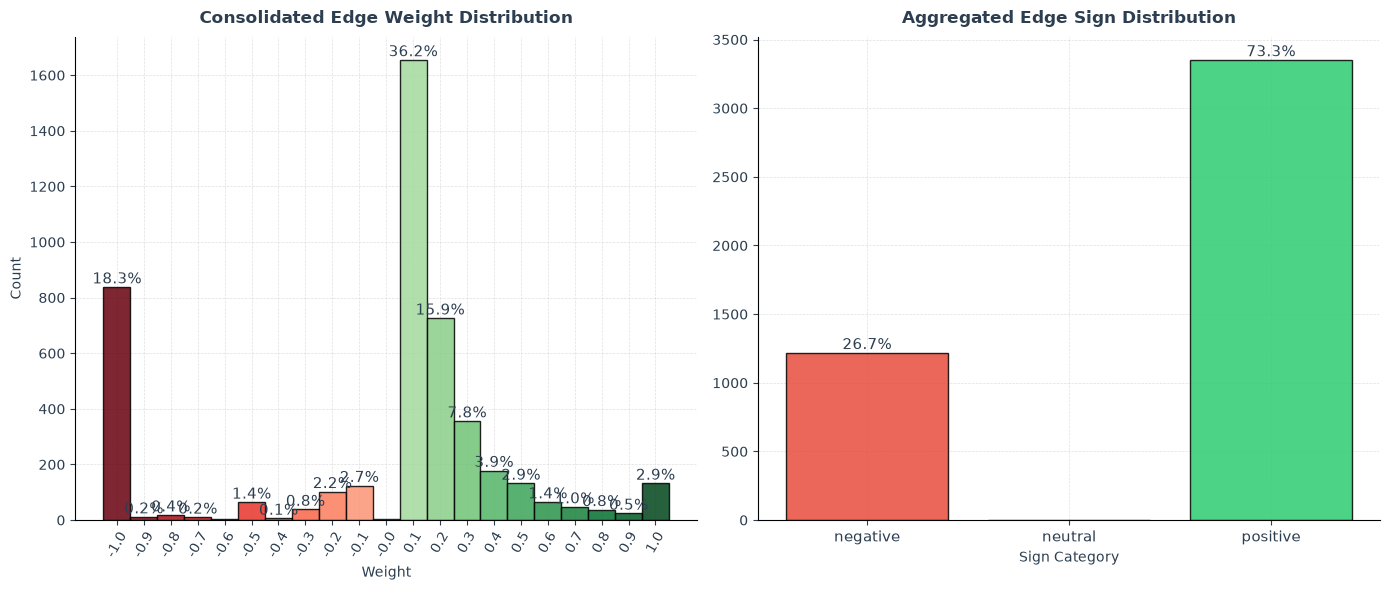

In [7]:
plot_weight_distribution(negative_graph)

In [8]:
# Null models for negative subgraphs
negative_null_models = [generate_null_model(negative_graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]
negative1_null_models = [generate_null_model(negative1_graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]

negative_triangles_graph = calculate_triangles_graph(negative_graph)
negative1_triangles_graph = calculate_triangles_graph(negative1_graph)
negative_null_triangles = calculate_triangles_null_graph(negative_null_models)
negative1_null_triangles = calculate_triangles_null_graph(negative1_null_models)

print("Negative Graph Balance Stats:")
print(calculate_balance_metrics(negative_graph, negative_null_models, NumberOfRandoms)[0])
print("\nNegative1 Graph Balance Stats:")
print(calculate_balance_metrics(negative1_graph, negative1_null_models, NumberOfRandoms)[0])

Negative Graph Balance Stats:
{'bw': 0.006336628192440929, 'mean': np.float64(0.04065485529693816), 'std': np.float64(0.0018793796988386135), 'z-score': np.float64(-18.260401091756293), 'percentile': np.float64(0.0)}

Negative1 Graph Balance Stats:
{'bw': 0.005954067199464584, 'mean': np.float64(0.035654593021979465), 'std': np.float64(0.0015245623617298556), 'z-score': np.float64(-19.48134531460882), 'percentile': np.float64(0.0)}


Negative Graph Triangle Configurations:
   0 pos edges  1 pos edge  2 pos edges  3 pos edges
0          187        2598         1139         7328

Negative1 Graph Triangle Configurations:
   0 pos edges  1 pos edge  2 pos edges  3 pos edges
0          189        2624         1334         9295


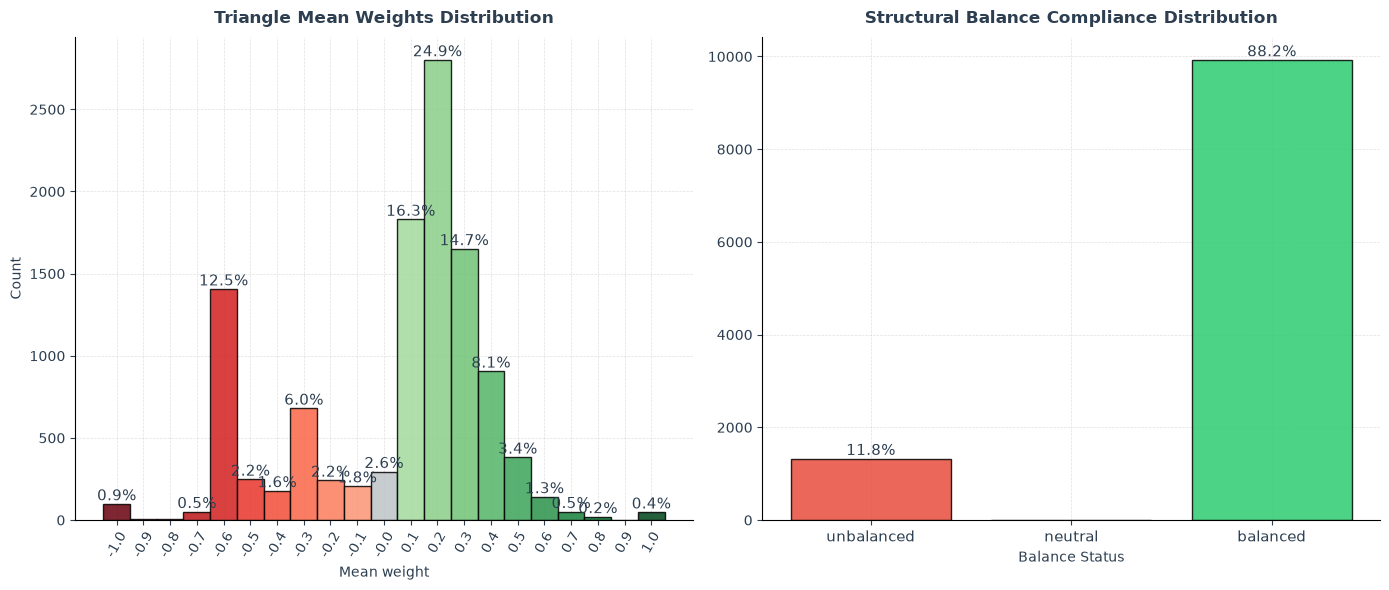

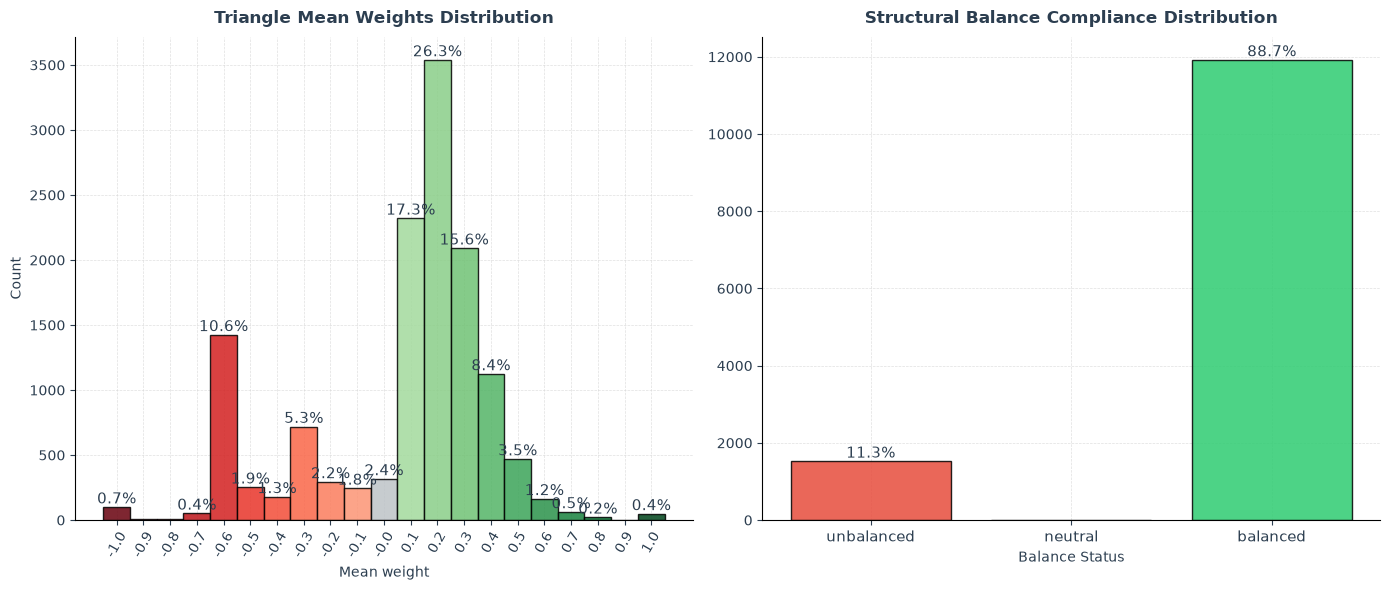

In [9]:
print("Negative Graph Triangle Configurations:")
print(number_of_triangles_per_type(negative_triangles_graph))
print("\nNegative1 Graph Triangle Configurations:")
print(number_of_triangles_per_type(negative1_triangles_graph))

plot_triangle_distribution(negative_triangles_graph)
plot_triangle_distribution(negative1_triangles_graph)

## 5. Continuous Graph Global Balance ($B_w$ Metric)
We analyze global balance using the continuous graph weights. We call `get_balance_analysis_results` with `recompute=False` to load the null distribution from cache (`distribution.json`). Toggle `recompute=True` to run the Monte Carlo simulation from scratch.

In [10]:
results_b, distributions_b = get_balance_analysis_results(
    graph, 
    null_models, 
    NumberOfRandoms, 
    recompute=False, 
    cache_path='distribution.json'
)
results_b

{'bw': 0.006356191342772418,
 'mean': np.float64(0.022409856500000002),
 'std': np.float64(0.0008559929050341188),
 'z-score': np.float64(-18.75443717210215),
 'percentile': np.float64(0.0)}

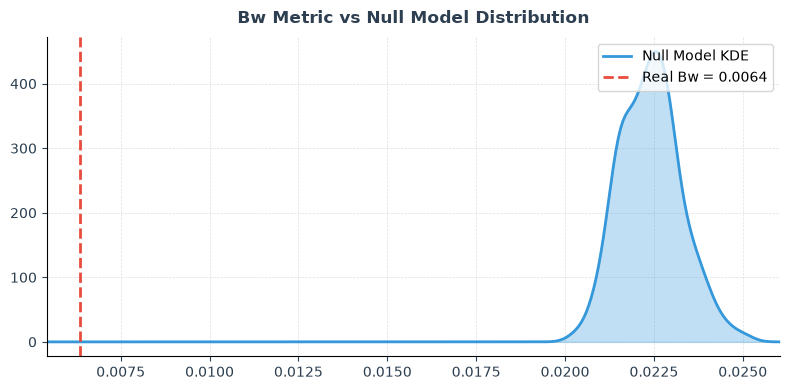

In [11]:
plot_bw_distribution(distributions_b, results_b)

We calculate the Kolmogorov-Smirnov statistics of the continuous graph and plot it.

In [12]:
D_results, D_distribution = calculate_kolmogorov_stats(triangles_graph, null_triangles)
D_results

{'D': 8716.703333333335,
 'mean': np.float64(298.63407777777775),
 'std': np.float64(118.50121446979425),
 'z-score': np.float64(71.03783107388583),
 'percentile': np.float64(100.0)}

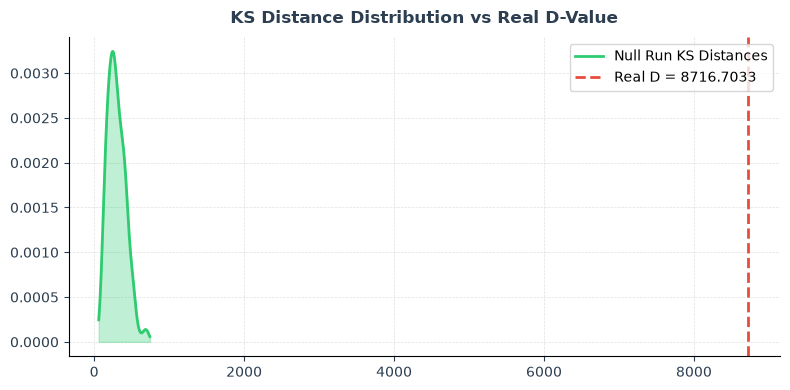

In [13]:
plot_kolmogorov(D_distribution, D_results)

## 6. Binary Graph Global Balance ($B_w$ Metric)
We repeat the global balance analysis for the binary simplified graph, using precomputed cache `BINARYdistributions_b.json` by default.

In [14]:
BINARYgraph = simplify_graph(graph_raw, std_threshold, continuous=False)
BINARYnull_models = [generate_null_model(BINARYgraph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]
BINARYtriangles_graph = calculate_triangles_graph(BINARYgraph)
BINARYnull_triangles = calculate_triangles_null_graph(BINARYnull_models)

print(f"Binary Graph: {BINARYgraph.number_of_nodes()} nodes, {BINARYgraph.number_of_edges()} edges")

Binary Graph: 5866 nodes, 21219 edges


In [15]:
BINARYresults_b, BINARYdistributions_b = get_balance_analysis_results(
    BINARYgraph, 
    BINARYnull_models, 
    NumberOfRandoms, 
    recompute=False, 
    cache_path='BINARYdistributions_b.json'
)
BINARYresults_b

{'bw': 0.0063561913427724465,
 'mean': np.float64(0.022248937835484036),
 'std': np.float64(0.0007445656242391126),
 'z-score': np.float64(-21.34499092535023),
 'percentile': np.float64(0.0)}

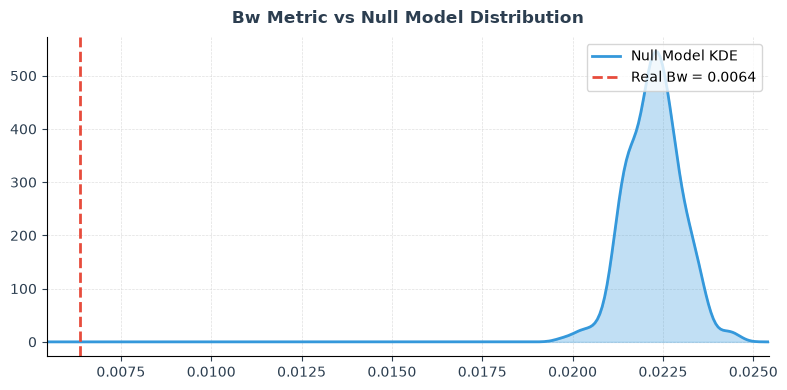

In [16]:
plot_bw_distribution(BINARYdistributions_b, BINARYresults_b)

In [17]:
BINARY_D_results, BINARY_D_distribution = calculate_kolmogorov_stats(BINARYtriangles_graph, BINARYnull_triangles)
BINARY_D_results

{'D': 6524.266666666666,
 'mean': np.float64(159.76844444444444),
 'std': np.float64(121.1334238846764),
 'z-score': np.float64(52.541222877357654),
 'percentile': np.float64(100.0)}

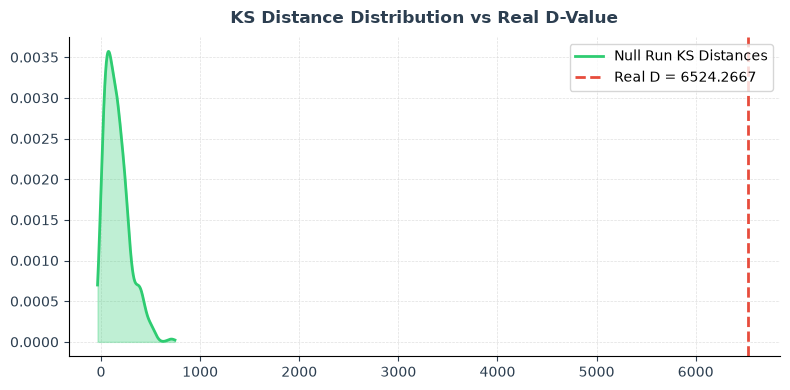

In [18]:
plot_kolmogorov(BINARY_D_distribution, BINARY_D_results)

## 7. Local Node-Level Profiling (Top-5 Degrees)
We analyze the local signed neighborhoods and balance statistics for the top-5 nodes by degree.

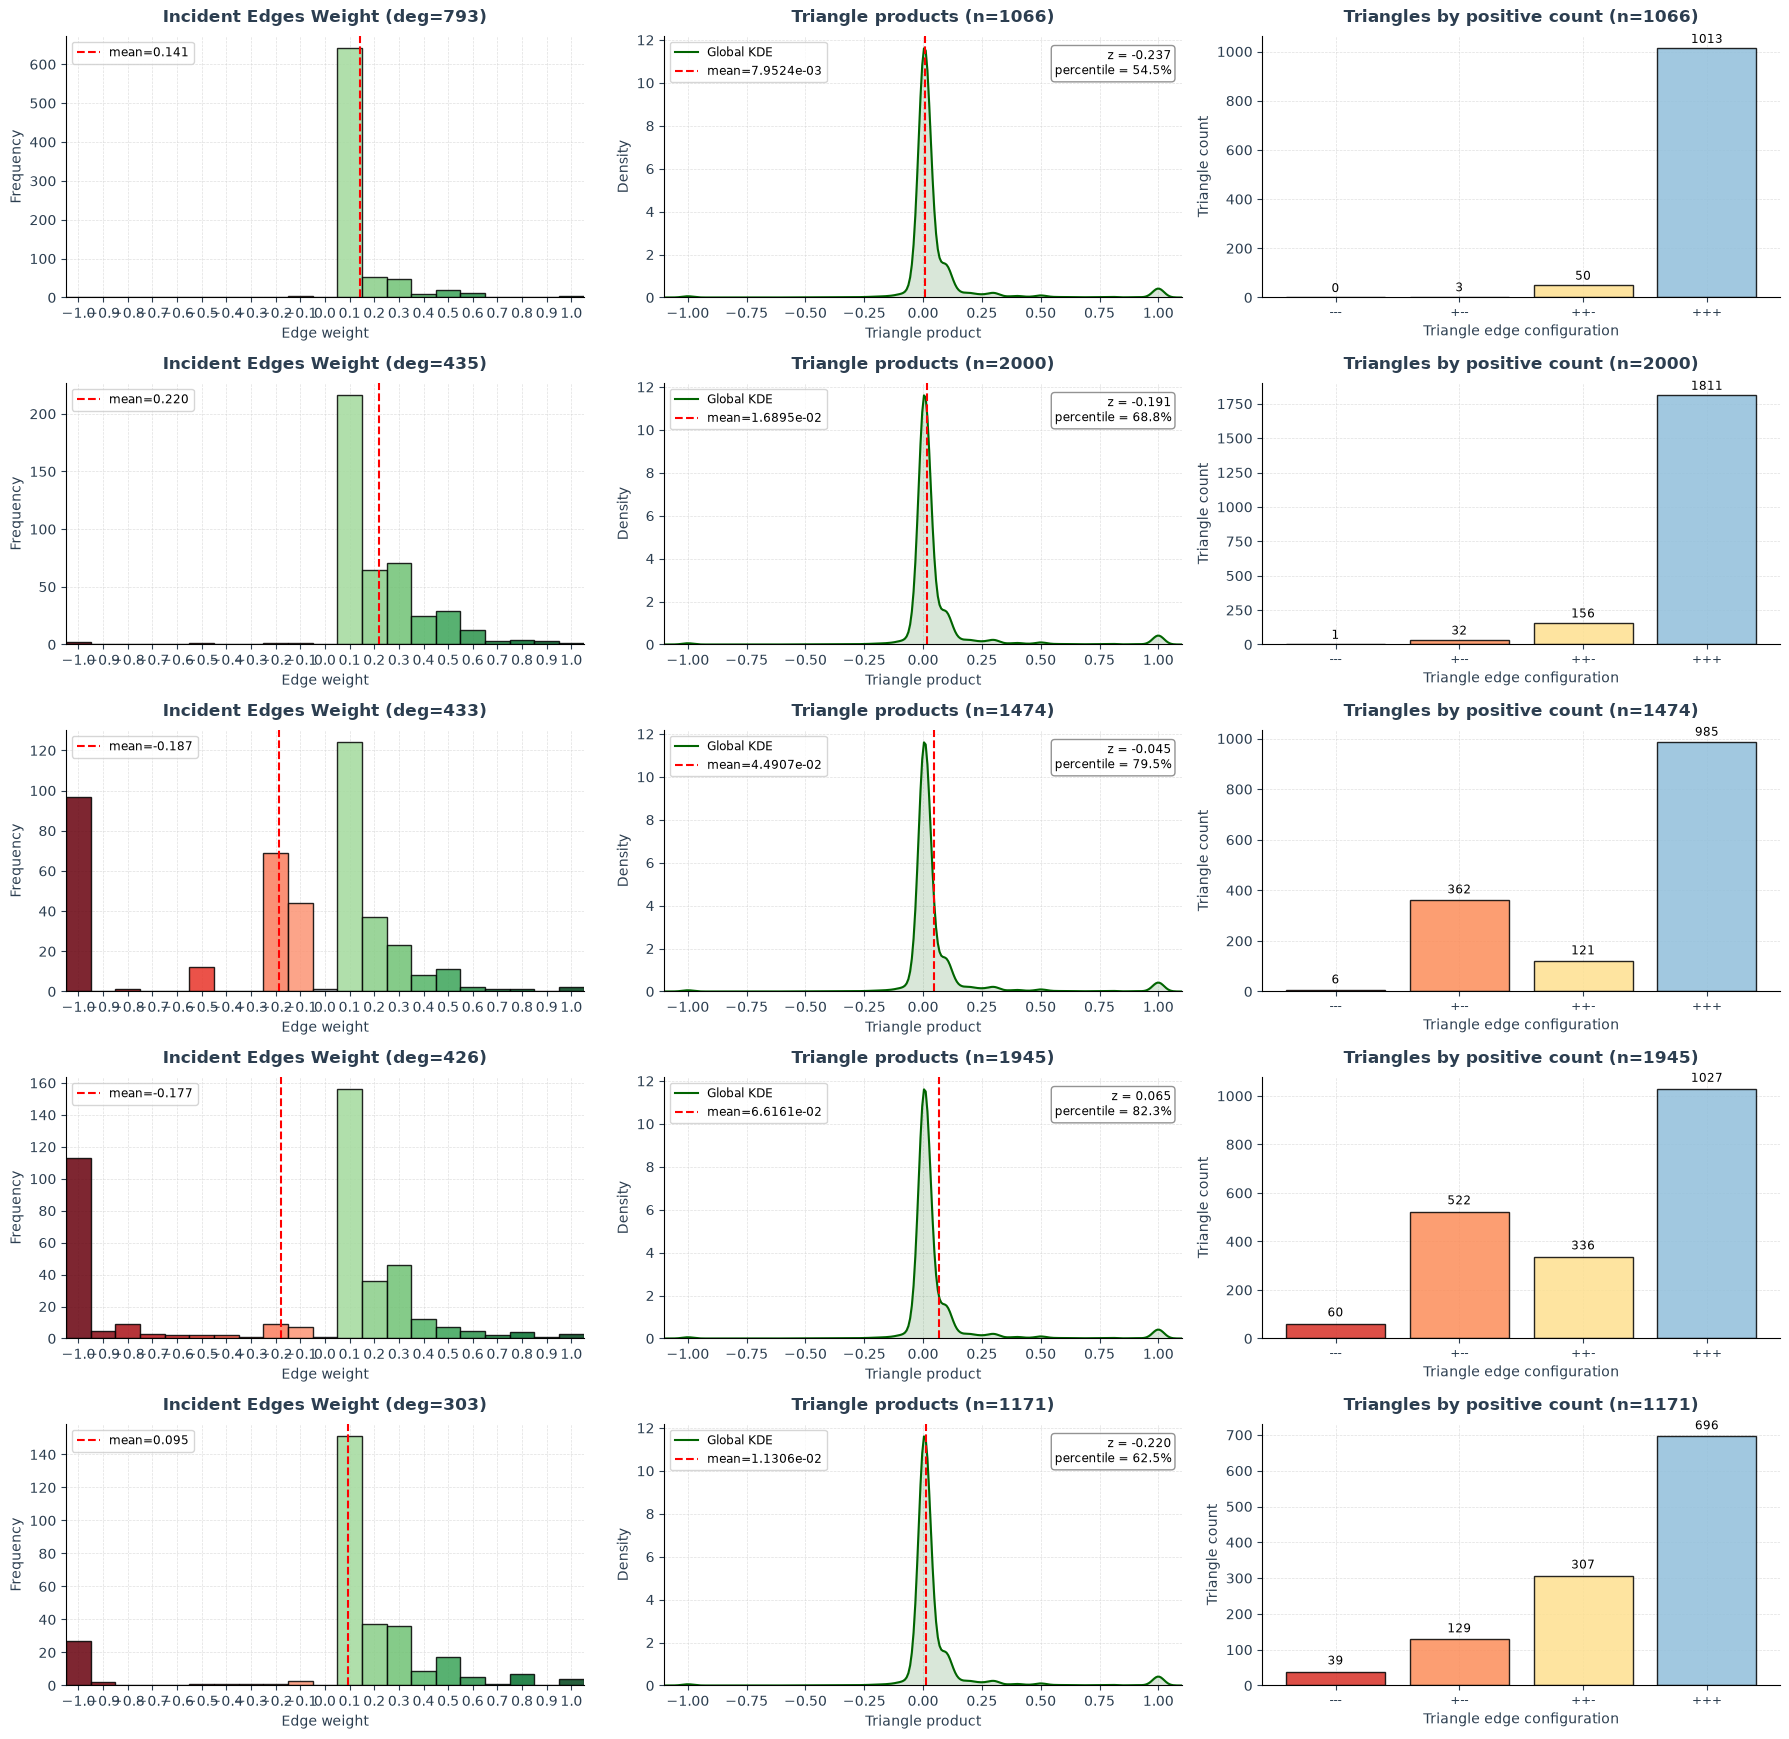

In [19]:
top_nodes_stats(graph, 5)

## 8. Cohesive Fraudster Group Detection
We run our candidate-based community detection algorithm to identify cohesive, suspicious fraud groups across three parameter settings.

Config 1 (Relaxed): Detected 10 fraudster groups.


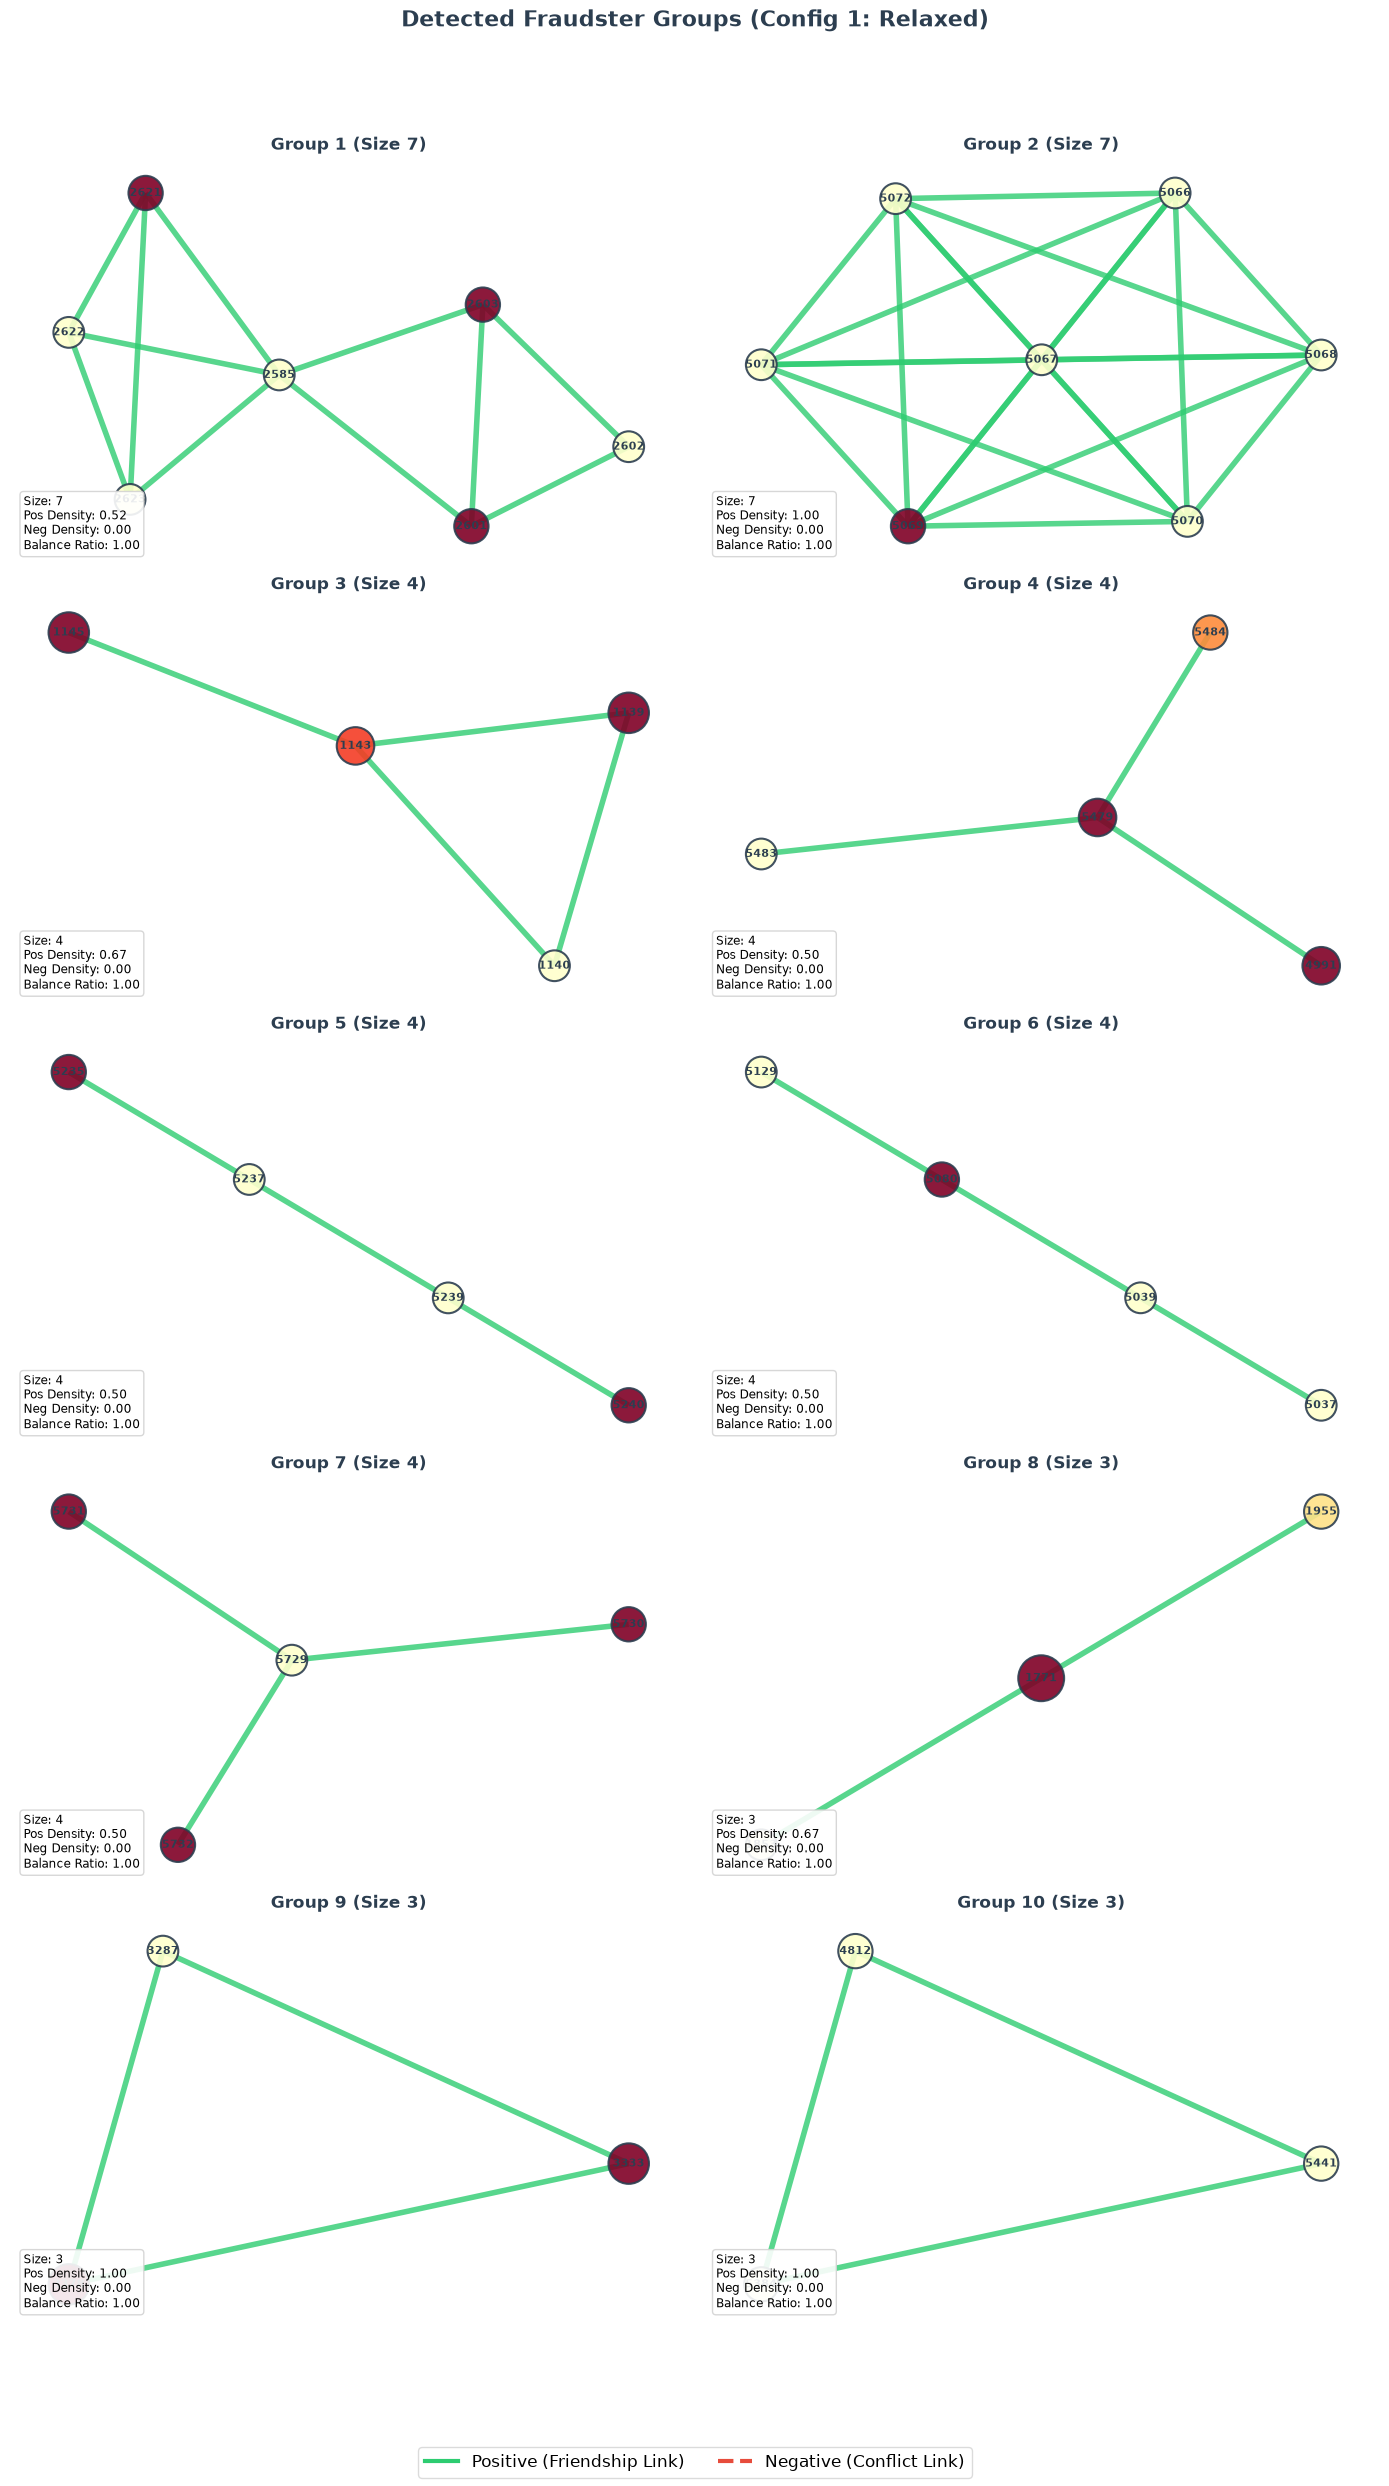

Config 2 (Moderate): Detected 4 fraudster groups.


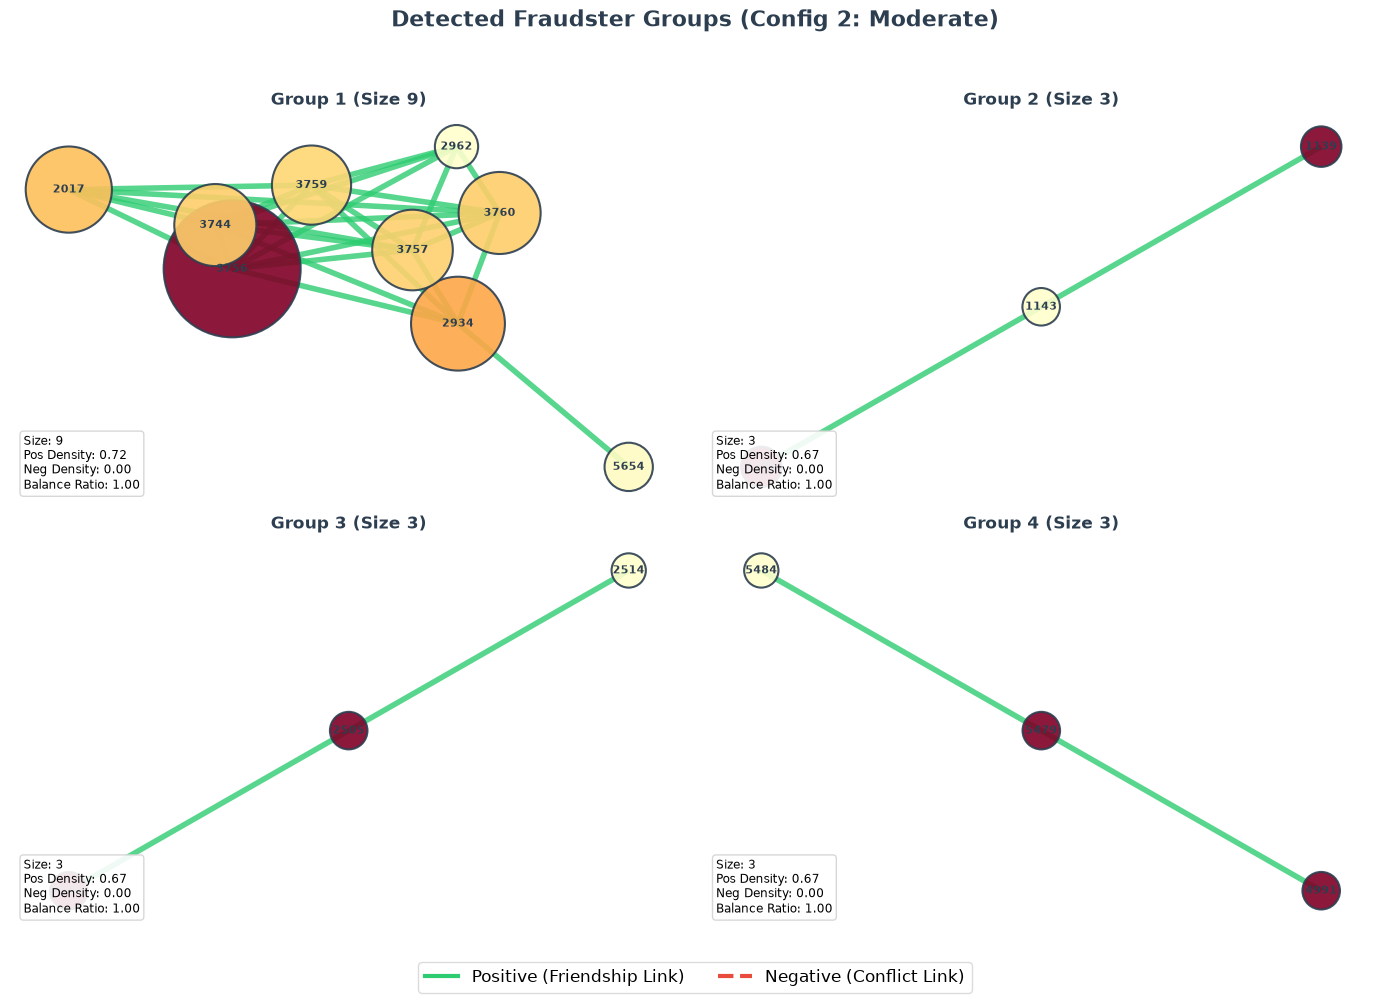

Config 3 (Strict): Detected 2 fraudster groups.


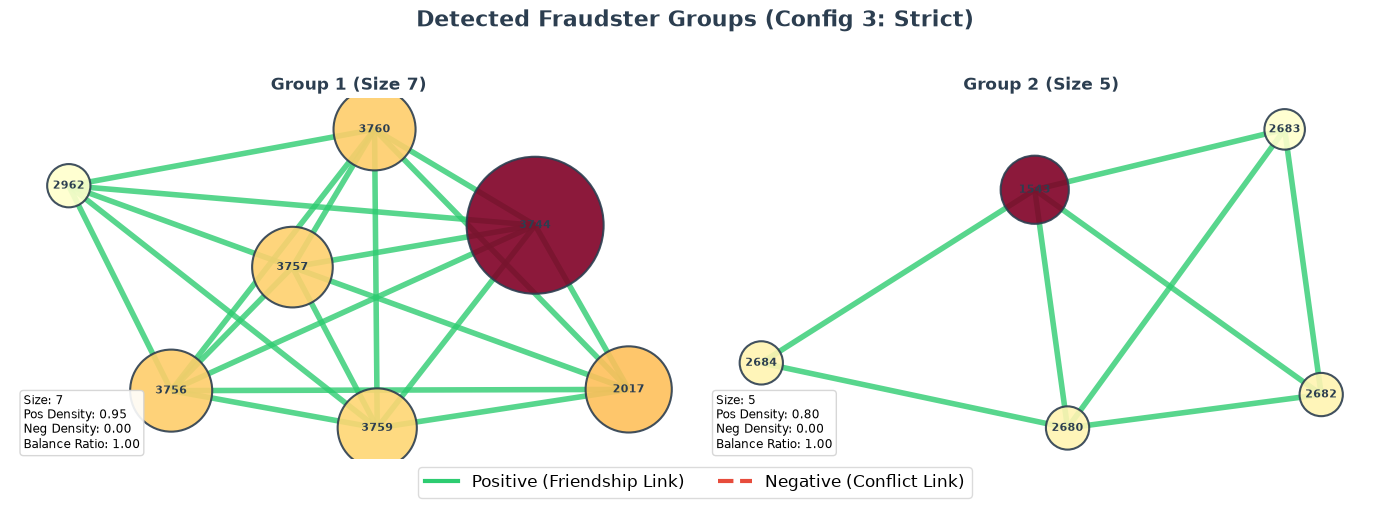

In [20]:
from auxiliary_functions import detect_fraudster_groups, plot_all_fraudster_groups

# Configuration 1: Relaxed Parameters
groups_c1 = detect_fraudster_groups(BINARYgraph, min_neg_degree=2, min_pos_density=0.5, min_balance_ratio=0.8)
print(f"Config 1 (Relaxed): Detected {len(groups_c1)} fraudster groups.")
if groups_c1:
    plot_all_fraudster_groups(BINARYgraph, groups_c1, title="Detected Fraudster Groups (Config 1: Relaxed)")

# Configuration 2: Moderate Parameters (Recommended)
groups_c2 = detect_fraudster_groups(BINARYgraph, min_neg_degree=3, min_pos_density=0.6, min_balance_ratio=0.85)
print(f"Config 2 (Moderate): Detected {len(groups_c2)} fraudster groups.")
if groups_c2:
    plot_all_fraudster_groups(BINARYgraph, groups_c2, title="Detected Fraudster Groups (Config 2: Moderate)")

# Configuration 3: Strict Parameters
groups_c3 = detect_fraudster_groups(BINARYgraph, min_neg_degree=4, min_pos_density=0.7, min_balance_ratio=0.9)
print(f"Config 3 (Strict): Detected {len(groups_c3)} fraudster groups.")
if groups_c3:
    plot_all_fraudster_groups(BINARYgraph, groups_c3, title="Detected Fraudster Groups (Config 3: Strict)")
